# LSTM KPI Analysis

Analyses LSTM forecast performance across **all available periods**.
Data is loaded from `KPI/lstm/` — the combined history from all pipeline runs.

## Periods covered
| Period | Months |
|--------|--------|
| Nov 2025 | November |
| Dec 2025 | December |
| Jan 2026 | February |

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"]  = 11
plt.rcParams["axes.grid"]  = True
plt.rcParams["grid.alpha"] = 0.3

LSTM_COLOR   = "#1f77b4"
ACTUAL_COLOR = "#2ca02c"
print("Setup complete.")

Setup complete.


## 2. Load Data

In [2]:
# All LSTM data (Nov 2025 - present) is pre-combined in KPI/lstm/
LSTM_DATA_PATH = "KPI/lstm"

# Period label mapping (month string -> display label)
PERIOD_MAP = {
    "2025-10": "Oct 2025",
    "2025-11": "Nov 2025",
    "2025-12": "Dec 2025",
    "2026-01": "Jan 2026",
    "2026-02": "Feb 2026",
}

# Load unified files
daily_kpis_raw   = pd.read_csv(f"{LSTM_DATA_PATH}/daily_kpis.csv", parse_dates=["date"])
monthly_kpis_raw = pd.read_csv(f"{LSTM_DATA_PATH}/monthly_kpis.csv")
actual_forecast  = pd.read_csv(f"{LSTM_DATA_PATH}/actual_forecast.csv", parse_dates=["datetime"])

# Assign period labels from month
daily_kpis_raw["period"] = (
    daily_kpis_raw["date"].dt.to_period("M").astype(str)
    .map(PERIOD_MAP).fillna("Other")
)

daily_kpis   = daily_kpis_raw.copy()
monthly_kpis = monthly_kpis_raw.copy()

# Ordered list of periods present in data
period_order = [v for v in PERIOD_MAP.values() if v in daily_kpis["period"].unique()]

print(f"LSTM data loaded from : {LSTM_DATA_PATH}")
print(f"30-min rows           : {len(actual_forecast)}")
print(f"Daily KPI rows        : {len(daily_kpis)}  "
      f"({daily_kpis['date'].min().date()} to {daily_kpis['date'].max().date()})")
print(f"Monthly KPI rows      : {len(monthly_kpis)}  (months: {list(monthly_kpis['month'])})")
print(f"Periods in data       : {period_order}")

LSTM data loaded from : KPI/lstm
30-min rows           : 5425
Daily KPI rows        : 114  (2025-10-31 to 2026-02-21)
Monthly KPI rows      : 5  (months: ['2025-10', '2025-11', '2025-12', '2026-01', '2026-02'])
Periods in data       : ['Oct 2025', 'Nov 2025', 'Dec 2025', 'Jan 2026', 'Feb 2026']


## 3. LSTM Monthly KPI Summary

In [3]:
print("=== LSTM Monthly KPI Summary ===")
display(monthly_kpis)

best_month  = monthly_kpis.loc[monthly_kpis["lstm_mae"].idxmin()]
worst_month = monthly_kpis.loc[monthly_kpis["lstm_mae"].idxmax()]
print(f"\nBest  month by MAE : {best_month['month']}  MAE={best_month['lstm_mae']:.4f}")
print(f"Worst month by MAE : {worst_month['month']}  MAE={worst_month['lstm_mae']:.4f}")

=== LSTM Monthly KPI Summary ===


,month,lstm_mae,lstm_rmse,lstm_smape
0,2025-10,2.337917,3.373120,20.141953
1,2025-11,1.509382,2.114030,16.774419
2,2025-12,1.317440,1.698470,12.588318
3,2026-01,1.303324,2.287735,10.342804
4,2026-02,1.475804,2.077545,13.662945



Best  month by MAE : 2026-01  MAE=1.3033
Worst month by MAE : 2025-10  MAE=2.3379


## 4. Actual vs LSTM Forecast — Full Timeline

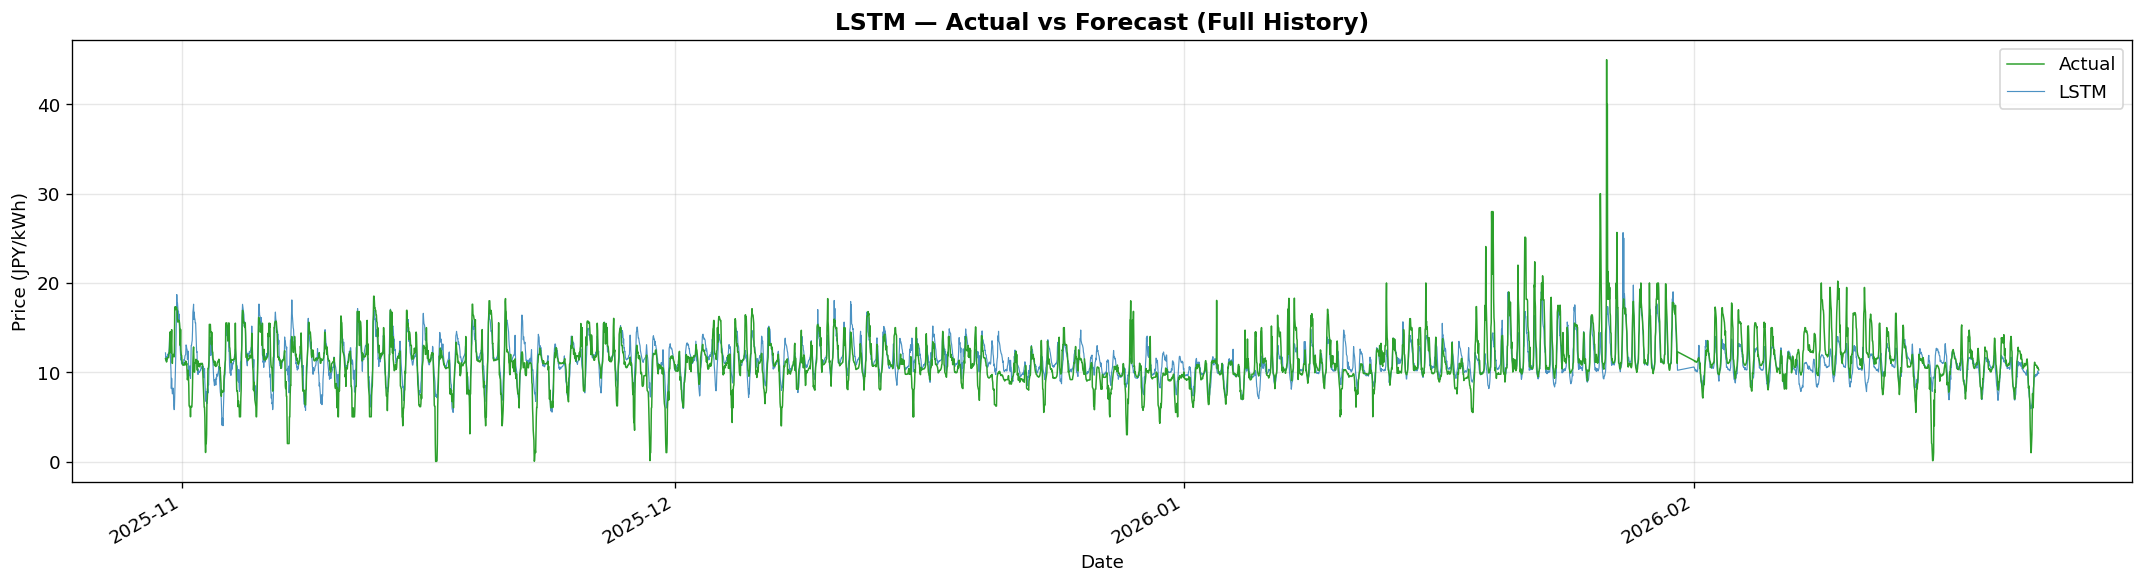

Plot saved.


In [4]:
af = actual_forecast.dropna(subset=["lstm_forecast"]).copy()

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(af["datetime"], af["actual_value"],  label="Actual", color=ACTUAL_COLOR, linewidth=0.9, zorder=3)
ax.plot(af["datetime"], af["lstm_forecast"], label="LSTM",   color=LSTM_COLOR,   linewidth=0.7, alpha=0.8)

ax.set_title("LSTM — Actual vs Forecast (Full History)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Price (JPY/kWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
ax.legend()
plt.tight_layout()
plt.savefig("KPI/lstm_actual_vs_forecast_full.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## 5. Daily KPI Trends

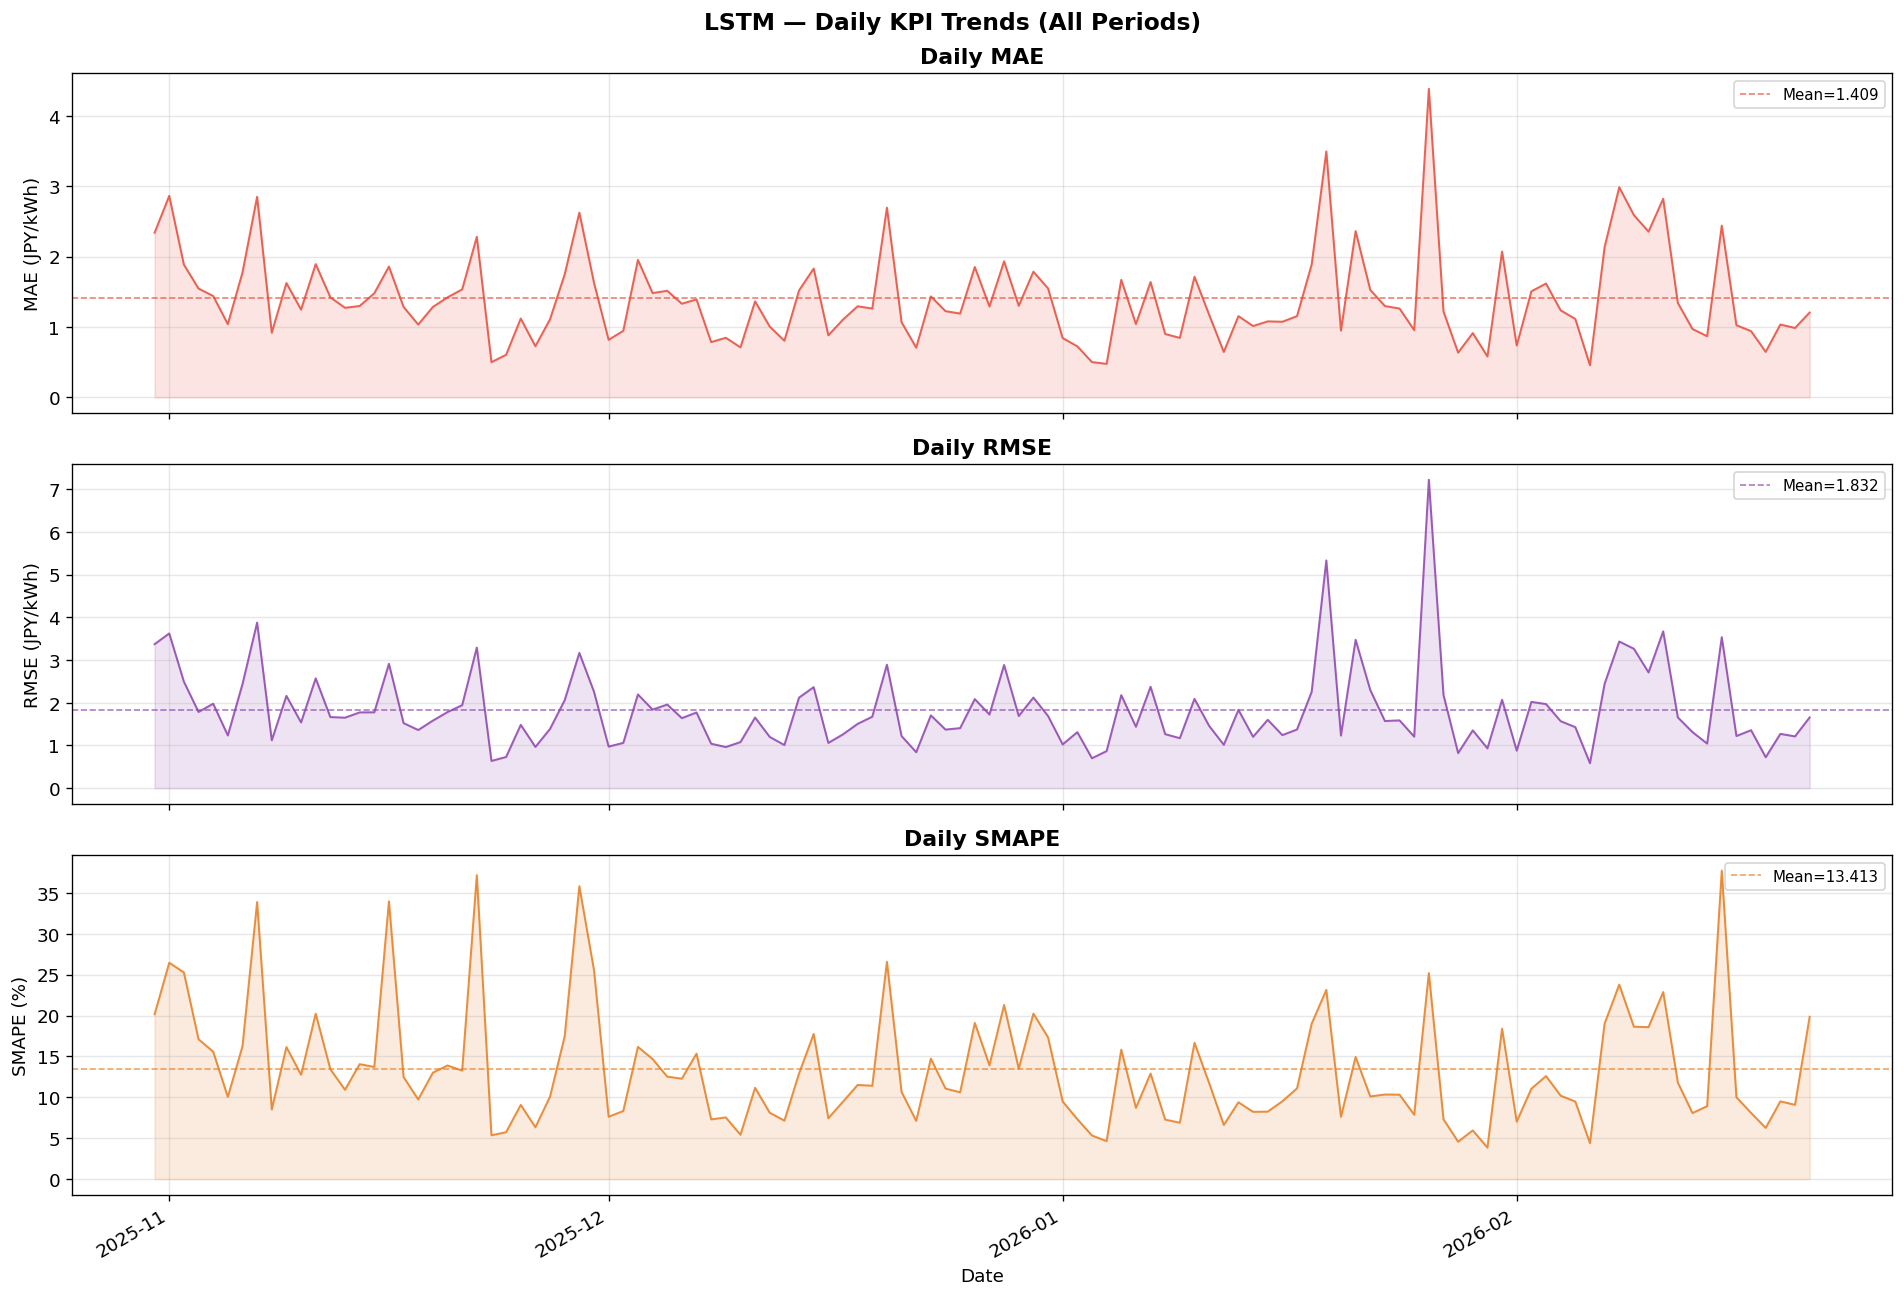

Plot saved.


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
metrics = ["lstm_mae", "lstm_rmse", "lstm_smape"]
labels  = ["MAE (JPY/kWh)", "RMSE (JPY/kWh)", "SMAPE (%)"]
colors  = ["#e74c3c", "#8e44ad", "#e67e22"]

for ax, m, lbl, color in zip(axes, metrics, labels, colors):
    valid = daily_kpis.dropna(subset=[m])
    ax.plot(valid["date"], valid[m], color=color, linewidth=1.2, alpha=0.85)
    ax.fill_between(valid["date"], valid[m], alpha=0.15, color=color)
    mean_val = valid[m].mean()
    ax.axhline(mean_val, color=color, linewidth=1, linestyle="--", alpha=0.7,
               label=f"Mean={mean_val:.3f}")
    ax.set_ylabel(lbl)
    ax.legend(fontsize=9)
    ax.set_title(f"Daily {m.split('_')[1].upper()}", fontweight="bold")

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
fig.suptitle("LSTM — Daily KPI Trends (All Periods)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("KPI/lstm_daily_kpi_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## 6. Monthly KPI Bar Chart

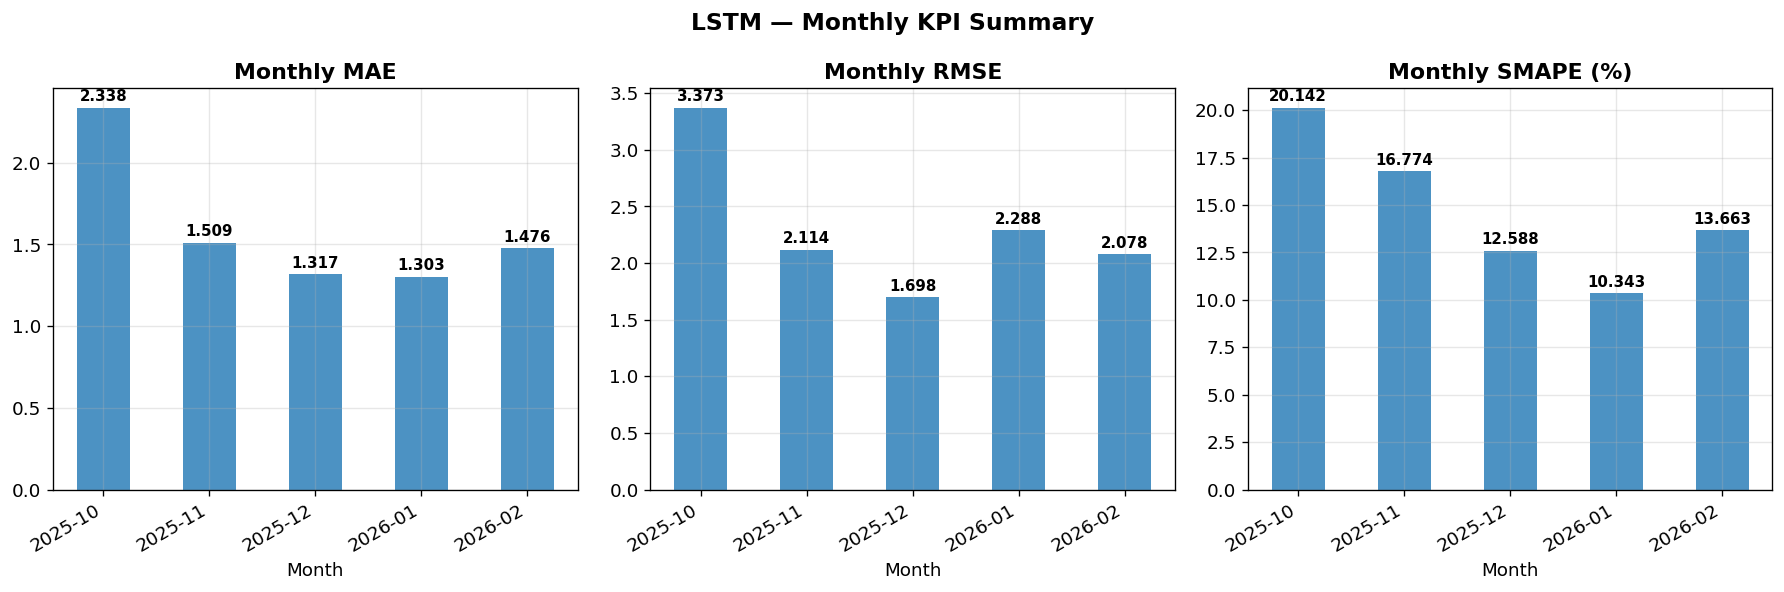

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ["lstm_mae", "lstm_rmse", "lstm_smape"]
titles  = ["Monthly MAE", "Monthly RMSE", "Monthly SMAPE (%)"]

for ax, m, title in zip(axes, metrics, titles):
    valid = monthly_kpis.dropna(subset=[m])
    bars = ax.bar(valid["month"], valid[m], color=LSTM_COLOR, alpha=0.8, width=0.5)
    max_val = valid[m].max()
    for bar, val in zip(bars, valid[m]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_val*0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_xticklabels(valid["month"], rotation=30, ha="right")

fig.suptitle("LSTM — Monthly KPI Summary", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("KPI/lstm_monthly_kpis.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Best & Worst Days

In [7]:
valid_daily = daily_kpis.dropna(subset=["lstm_mae"]).sort_values("lstm_mae")

print("=== Top 10 Best Days (lowest MAE) ===")
display(valid_daily.head(10)[["date", "period", "lstm_mae", "lstm_rmse", "lstm_smape"]])

print("\n=== Top 10 Worst Days (highest MAE) ===")
display(valid_daily.tail(10)[["date", "period", "lstm_mae", "lstm_rmse", "lstm_smape"]].iloc[::-1])

=== Top 10 Best Days (lowest MAE) ===


,date,period,lstm_mae,lstm_rmse,lstm_smape
98,2026-02-06,Feb 2026,0.455208,0.585835,4.401285
65,2026-01-04,Jan 2026,0.474792,0.868930,4.643794
23,2025-11-23,Nov 2025,0.498750,0.638328,5.354725
64,2026-01-03,Jan 2026,0.500000,0.701008,5.330397
91,2026-01-30,Jan 2026,0.580208,0.932730,3.854298
24,2025-11-24,Nov 2025,0.603542,0.730963,5.738508
89,2026-01-28,Jan 2026,0.634375,0.822586,4.576085
73,2026-01-12,Jan 2026,0.644167,1.016794,6.620137
110,2026-02-18,Feb 2026,0.645000,0.725488,6.260809
52,2025-12-22,Dec 2025,0.705208,0.843096,7.118397



=== Top 10 Worst Days (highest MAE) ===


,date,period,lstm_mae,lstm_rmse,lstm_smape
87,2026-01-26,Jan 2026,4.382917,7.224014,25.186896
80,2026-01-19,Jan 2026,3.493333,5.334183,23.135186
100,2026-02-08,Feb 2026,2.984583,3.435511,23.782327
1,2025-11-01,Nov 2025,2.862083,3.624436,26.452763
7,2025-11-07,Nov 2025,2.848958,3.878765,33.873706
103,2026-02-11,Feb 2026,2.820417,3.673119,22.872094
50,2025-12-20,Dec 2025,2.693750,2.891714,26.567377
29,2025-11-29,Nov 2025,2.623958,3.168085,35.809978
101,2026-02-09,Feb 2026,2.588542,3.265058,18.631952
107,2026-02-15,Feb 2026,2.439167,3.535899,37.711384


## 8. Error Distribution

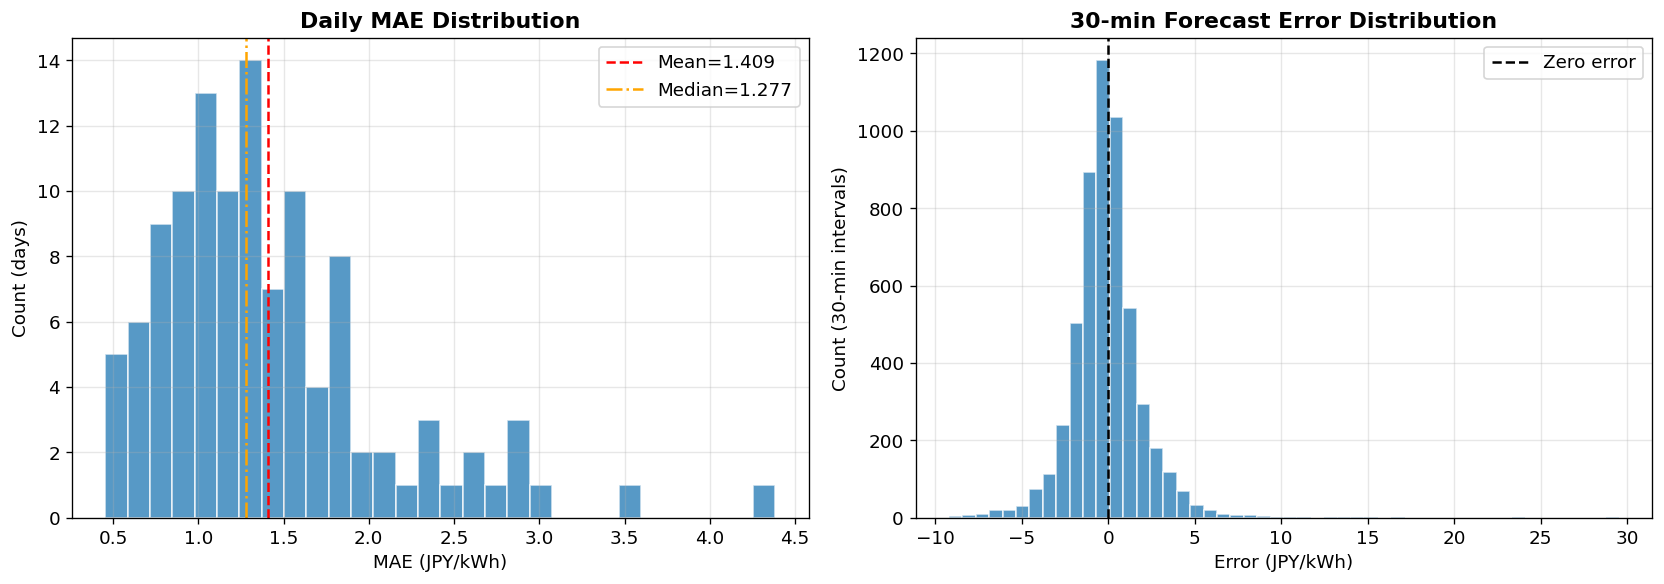

Plot saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Daily MAE histogram
ax = axes[0]
mae_vals = daily_kpis["lstm_mae"].dropna()
ax.hist(mae_vals, bins=30, color=LSTM_COLOR, alpha=0.75, edgecolor="white")
ax.axvline(mae_vals.mean(),   color="red",    linewidth=1.5, linestyle="--",
           label=f"Mean={mae_vals.mean():.3f}")
ax.axvline(mae_vals.median(), color="orange", linewidth=1.5, linestyle="-.",
           label=f"Median={mae_vals.median():.3f}")
ax.set_title("Daily MAE Distribution", fontweight="bold")
ax.set_xlabel("MAE (JPY/kWh)")
ax.set_ylabel("Count (days)")
ax.legend()

# 30-min error histogram
ax = axes[1]
err = (actual_forecast["actual_value"] - actual_forecast["lstm_forecast"]).dropna()
ax.hist(err, bins=50, color=LSTM_COLOR, alpha=0.75, edgecolor="white")
ax.axvline(0, color="black", linewidth=1.5, linestyle="--", label="Zero error")
ax.set_title("30-min Forecast Error Distribution", fontweight="bold")
ax.set_xlabel("Error (JPY/kWh)")
ax.set_ylabel("Count (30-min intervals)")
ax.legend()

plt.tight_layout()
plt.savefig("KPI/lstm_error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## 9. Period-by-Period Comparison (Box-Plots)

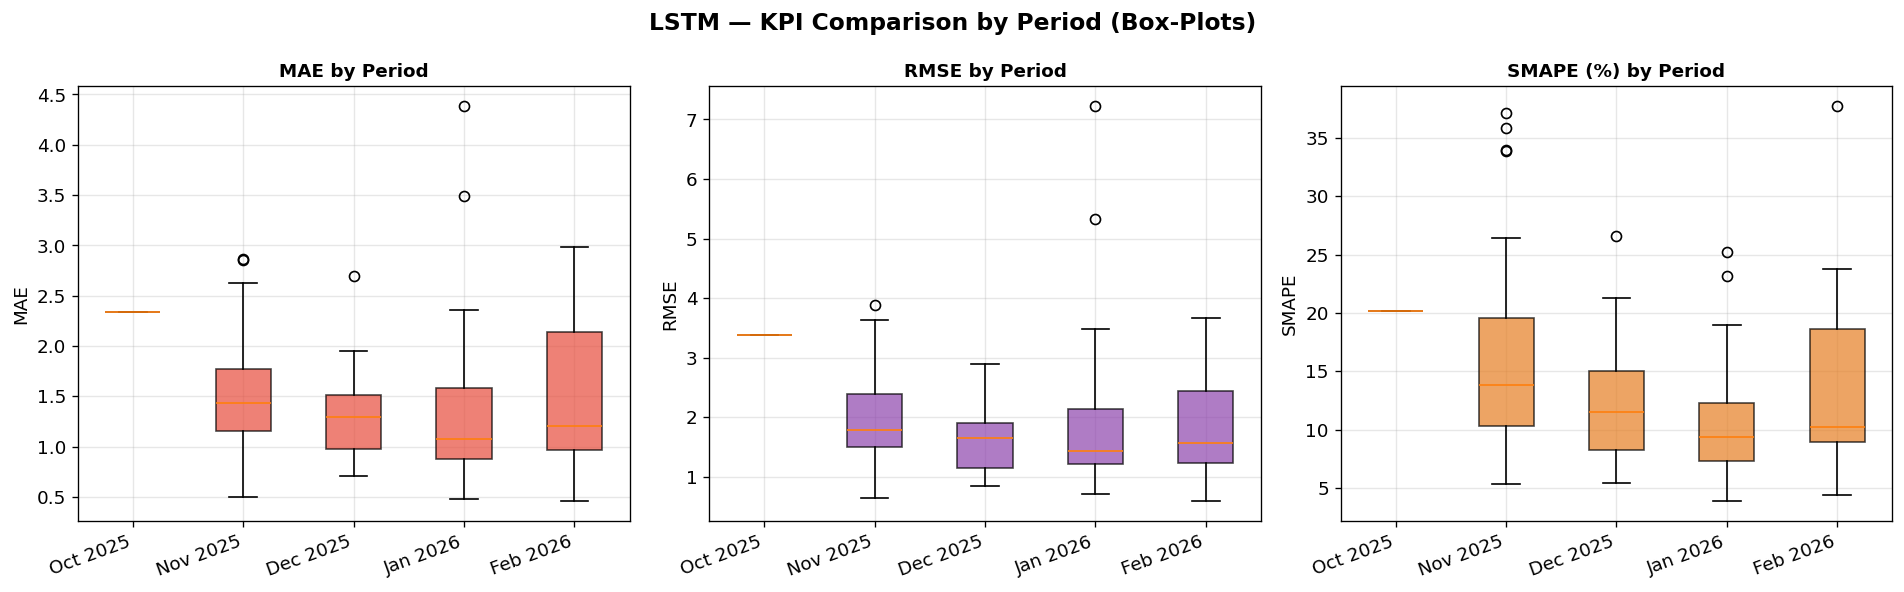

Plot saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bx_metrics = ["lstm_mae", "lstm_rmse", "lstm_smape"]
bx_titles  = ["MAE by Period", "RMSE by Period", "SMAPE (%) by Period"]
bx_colors  = ["#e74c3c", "#8e44ad", "#e67e22"]

for ax, col, title, color in zip(axes, bx_metrics, bx_titles, bx_colors):
    data = [daily_kpis[daily_kpis["period"] == p][col].dropna().values
            for p in period_order]
    bp = ax.boxplot(data, labels=period_order, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticklabels(period_order, rotation=20, ha="right")
    ax.set_ylabel(col.split("_")[-1].upper())

fig.suptitle("LSTM — KPI Comparison by Period (Box-Plots)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("KPI/lstm_period_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## 10. Intra-Day Error Pattern

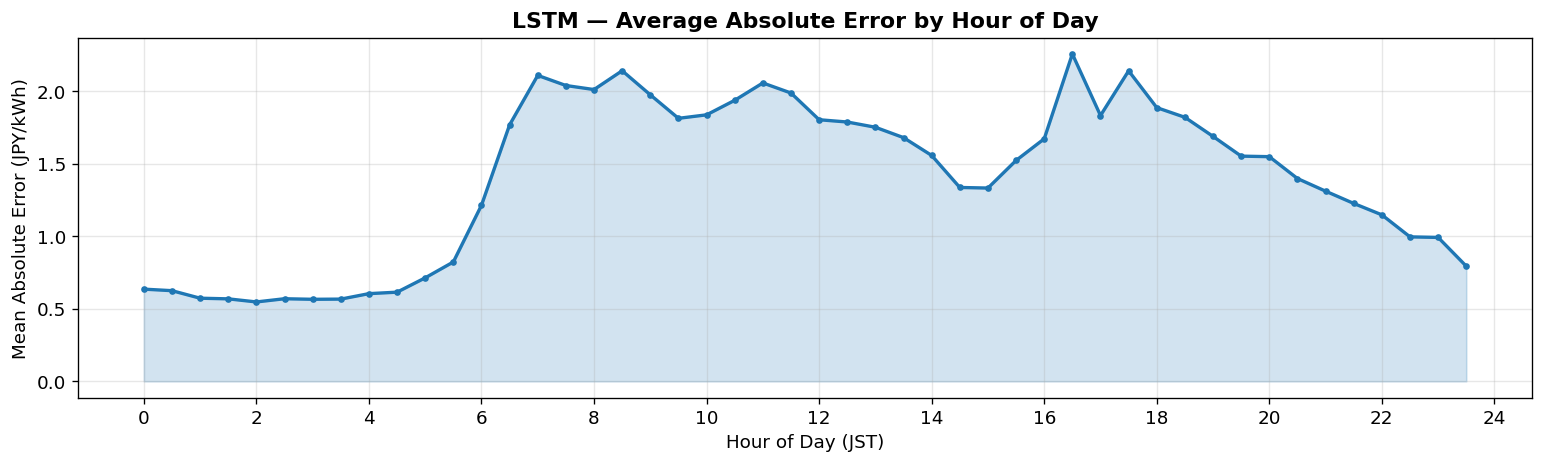

Plot saved.


In [10]:
af_valid = actual_forecast.dropna(subset=["lstm_forecast"]).copy()
af_valid["hour"]      = af_valid["datetime"].dt.hour + af_valid["datetime"].dt.minute / 60
af_valid["abs_error"] = (af_valid["actual_value"] - af_valid["lstm_forecast"]).abs()

hourly_err = af_valid.groupby("hour")["abs_error"].mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(hourly_err.index, hourly_err.values, color=LSTM_COLOR, linewidth=2,
        marker="o", markersize=3)
ax.fill_between(hourly_err.index, hourly_err.values, alpha=0.2, color=LSTM_COLOR)
ax.set_title("LSTM — Average Absolute Error by Hour of Day", fontweight="bold")
ax.set_xlabel("Hour of Day (JST)")
ax.set_ylabel("Mean Absolute Error (JPY/kWh)")
ax.set_xticks(range(0, 25, 2))
plt.tight_layout()
plt.savefig("KPI/lstm_intraday_error.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## 11. Key Insights & Summary

In [11]:
print("=" * 60)
print("  LSTM KPI ANALYSIS SUMMARY")
print(f"  Data: {LSTM_DATA_PATH}  |  Area: Tohoku")
print("=" * 60)

valid = daily_kpis.dropna(subset=["lstm_mae"])
print(f"  Total days analysed  : {len(valid)}")
print(f"  Date range           : {valid['date'].min().date()} to {valid['date'].max().date()}")
print(f"  Periods              : {period_order}")
print()
print(f"  Overall daily MAE    : {valid['lstm_mae'].mean():.4f}  (std={valid['lstm_mae'].std():.4f})")
print(f"  Overall daily RMSE   : {valid['lstm_rmse'].mean():.4f}  (std={valid['lstm_rmse'].std():.4f})")
print(f"  Overall daily SMAPE  : {valid['lstm_smape'].mean():.4f}%")
print()
print("  Monthly MAE breakdown:")
for _, row in monthly_kpis.dropna(subset=["lstm_mae"]).iterrows():
    flag = " <- best"  if row["lstm_mae"] == monthly_kpis["lstm_mae"].min() else \
           " <- worst" if row["lstm_mae"] == monthly_kpis["lstm_mae"].max() else ""
    print(f"    {row['month']}: MAE={row['lstm_mae']:.4f}{flag}")
print()
best_day  = valid.loc[valid["lstm_mae"].idxmin()]
worst_day = valid.loc[valid["lstm_mae"].idxmax()]
print(f"  Best  day: {best_day['date'].date()}  MAE={best_day['lstm_mae']:.4f}")
print(f"  Worst day: {worst_day['date'].date()}  MAE={worst_day['lstm_mae']:.4f}")
print("=" * 60)

  LSTM KPI ANALYSIS SUMMARY
  Data: KPI/lstm  |  Area: Tohoku
  Total days analysed  : 114
  Date range           : 2025-10-31 to 2026-02-21
  Periods              : ['Oct 2025', 'Nov 2025', 'Dec 2025', 'Jan 2026', 'Feb 2026']

  Overall daily MAE    : 1.4088  (std=0.6673)
  Overall daily RMSE   : 1.8324  (std=0.9595)
  Overall daily SMAPE  : 13.4127%

  Monthly MAE breakdown:
    2025-10: MAE=2.3379 <- worst
    2025-11: MAE=1.5094
    2025-12: MAE=1.3174
    2026-01: MAE=1.3033 <- best
    2026-02: MAE=1.4758

  Best  day: 2026-02-06  MAE=0.4552
  Worst day: 2026-01-26  MAE=4.3829
